In [2]:
from google.colab import userdata
import os
userdata.get('kaggle_key')
os.environ['kaggle_key'] = userdata.get('kaggle_key')

In [3]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
Tesla T4


# Make the random number generations reproducible

In [4]:
import numpy as np
import random
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True

In [5]:
!pip install kagglehub

In [6]:
import kagglehub

In [7]:
path = kagglehub.dataset_download("anujms/car-damage-detection")

100%|██████████| 123M/123M [00:01<00:00, 125MB/s]

Extracting files...


In [8]:
root_dir = os.path.join(path, 'data1a', 'training')

In [9]:
import pandas as pd, numpy as np, sklearn

In [10]:
from PIL import Image
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
import math
from torchvision import transforms
from torchvision import models
import torch.nn as nn
import torch.optim as optim


In [11]:
print(root_dir)
print(os.path.exists(root_dir))
print(os.listdir(root_dir))

/root/.cache/kagglehub/datasets/anujms/car-damage-detection/versions/1/data1a/training
True
['00-damage', '01-whole']


In [12]:
valid_root_dir = os.path.join(path, 'data1a', 'validation')
print(os.path.exists(valid_root_dir))
print(os.listdir(valid_root_dir))

True
['00-damage', '01-whole']


In [13]:
import os

train_damage = os.listdir(os.path.join(root_dir, '00-damage'))
train_whole = os.listdir(os.path.join(root_dir, '01-whole'))
print(len(train_damage), len(train_whole))

valid_damage = os.listdir(os.path.join(valid_root_dir, '00-damage'))
valid_whole = os.listdir(os.path.join(valid_root_dir, '01-whole'))
print(len(valid_damage), len(valid_whole))

920 920
230 230


In [14]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

#  Custom Dataset class

CarDamageDataset — loads images from the dataframe, applies transforms, returns (image, label) pairs.

In [15]:
class CarDamageDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.dataframe = dataframe #stores train or valid df so __getitem__ can access it
        self.root_dir = root_dir #stores the root directory of the dataset so __getitem__ can access it
        self.transform = transform #Stores the transform so __getitem__ can access it
        self.folder_map = {0: "00-damage", 1: "01-whole"}


    def __len__(self):
        return(len(self.dataframe))

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx] #grabs the row index idx
        label = row['label']
        filename = row['path']

        folder = self.folder_map[label]
        img_path = os.path.join(self.root_dir, folder, filename)
        image = Image.open(img_path).convert('RGB') # forcing 3 channels in case of grayscale images  (RGB)

        if self.transform:
            image = self.transform(image)

        return image, label

In [16]:
train_df = pd.DataFrame({
    'path': train_damage + train_whole,
    'label': [0] * len(train_damage) + [1] * len(train_whole)
})
valid_df = pd.DataFrame({
    'path': valid_damage + valid_whole,
    'label': [0] * len(valid_damage) + [1] * len(valid_whole)
})
#
valid_df.tail()

,path,label
455,0184.jpg,1
456,0113.jpg,1
457,0216.JPEG,1
458,0135.jpg,1
459,0150.jpg,1


# transofrm for the training and validation images

In [17]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness = 0.2, contrast=0.2, saturation= 0.2),
    transforms.ToTensor()
])

valid_transform  = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [18]:
train_dataset = CarDamageDataset(train_df, root_dir, transform= train_transform)
valid_dataset = CarDamageDataset(valid_df, valid_root_dir, transform= valid_transform)

In [19]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
valid_loader = DataLoader(valid_dataset, batch_size = 32, shuffle = True)

In [20]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [21]:
model = torchvision.models.resnet18(pretrained = True)
model.fc = nn.Linear(model.fc.in_features, 2)
model.to(device)

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 55.0MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [22]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode = 'min', patience= 2,factor = 0.1)

In [23]:
images, labels = next(iter(train_loader))
print(images.shape, labels.shape)

torch.Size([32, 3, 224, 224]) torch.Size([32])


## Training loop

Trains for 10 epochs with per-epoch validation tracking, saves the best performing weights to `best_model.pth`, and reduces the learning rate on plateauing validation loss.

In [24]:
val_acc = []
val_loss = []
train_losses = []
num_epochs = 10
best_val = 0.0

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    train_losses.append(running_loss / len(train_dataset))

    model.eval()
    correct = 0
    total = 0
    val_loss_sum = 0.0

    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            val_loss_sum += loss.item()

    epoch_val_acc = correct / total
    epoch_val_loss = val_loss_sum / len(valid_loader)

    scheduler.step(epoch_val_loss)

    if epoch_val_acc > best_val:
        best_val = epoch_val_acc
        torch.save(model.state_dict(), 'best_model.pth')
    val_acc.append(epoch_val_acc)
    val_loss.append(epoch_val_loss)

    model.train()
    print(f"Epoch {epoch+1}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")
    print(optimizer.param_groups[0]['lr'])

Epoch 1, Train Loss: 0.4696, Val Loss: 0.6378, Val Acc: 0.7587
0.001
Epoch 2, Train Loss: 0.2715, Val Loss: 0.4092, Val Acc: 0.7804
0.001
Epoch 3, Train Loss: 0.2351, Val Loss: 0.4794, Val Acc: 0.8217
0.001
Epoch 4, Train Loss: 0.2287, Val Loss: 0.3386, Val Acc: 0.8696
0.001
Epoch 5, Train Loss: 0.1964, Val Loss: 0.1827, Val Acc: 0.9348
0.001
Epoch 6, Train Loss: 0.1810, Val Loss: 0.5172, Val Acc: 0.7935
0.001
Epoch 7, Train Loss: 0.1832, Val Loss: 0.2527, Val Acc: 0.9174
0.001
Epoch 8, Train Loss: 0.2050, Val Loss: 0.5948, Val Acc: 0.7717
0.0001
Epoch 9, Train Loss: 0.1143, Val Loss: 0.1080, Val Acc: 0.9587
0.0001
Epoch 10, Train Loss: 0.0804, Val Loss: 0.1102, Val Acc: 0.9674
0.0001


# load best_model.pth and reruns validation to confirm accuracy on saved weights

In [25]:
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

true_labels = []
predicted_labels = []
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in valid_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        true_labels += labels.tolist()
        predicted_labels += predicted.tolist()

print(f"Correct: {correct}, Total: {total}")
accuracy = correct / total
print(f"Validation Accuracy: {accuracy:.4f}")

Correct: 445, Total: 460
Validation Accuracy: 0.9674


# confusion matrix to see what the model gets right and wrong

array([[222,   8],
       [  7, 223]])

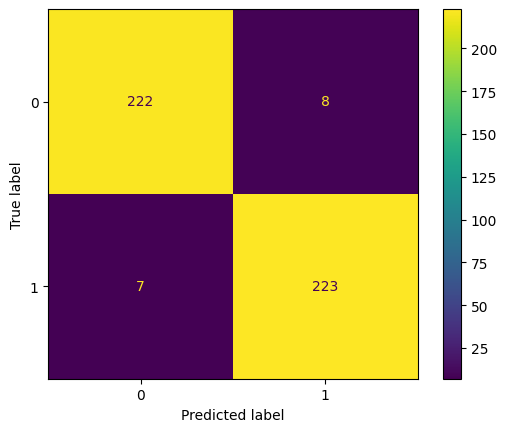

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(true_labels, predicted_labels)
display_cm = ConfusionMatrixDisplay(cm)
display_cm.plot()
cm

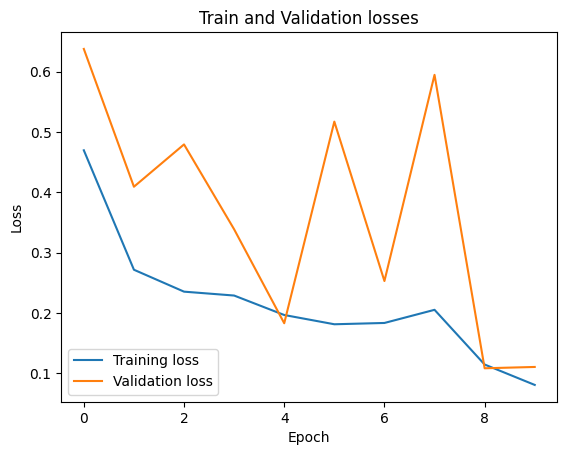

In [27]:
plt.plot(train_losses, label = 'Training loss')
plt.plot(val_loss, label = 'Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train and Validation losses')
plt.legend()
plt.show()

In [28]:
print(len(val_loss),
print(val_loss))

[0.6377945224444072, 0.40918505787849424, 0.47937178512414297, 0.3385834187269211, 0.1827203427751859, 0.5171832968791326, 0.2527482906977336, 0.594798884789149, 0.10802859539786974, 0.11020724376042684]
10 None


In [29]:
import torch.nn.functional as F
from PIL import Image

activations= {}
gradients = {}

def forward_hook(module, input, output):
  activations['value'] = output

def backward_hook(module, grad_input, grad_output):
  gradients['value'] = grad_output[0]

target_layer =model.layer4[-1]
target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)

def generate_gradcam(image_tensor, model, class_idx = None):
  model.eval()
  image_tensor = image_tensor.unsqueeze(0).to(device)

  output = model(image_tensor)
  if class_idx is None:
    class_idx = output.argmax(dim=1).item()

  model.zero_grad( )
  output[0, class_idx].backward()

  acts = activations['value'][0]
  grads = gradients['value'][0]

  weights = grads.mean(dim=(1,2))

  cam = torch.zeros(acts.shape[1:], device=device)
  for i, w in enumerate(weights):
    cam += w * acts[i]

  cam = F.relu(cam)
  cam = cam.cpu().detach().numpy()
  cam = cam / cam.max()

  return cam, class_idx


In [30]:
import os

sample_row = valid_df[valid_df['label'] == 0].iloc[0]  # label 0 = damage
img_path = os.path.join(valid_root_dir, "00-damage", sample_row['path'])
print(img_path)
print(os.path.exists(img_path))

/root/.cache/kagglehub/datasets/anujms/car-damage-detection/versions/1/data1a/validation/00-damage/0036.JPEG
True


In [31]:
print(img_path)

/root/.cache/kagglehub/datasets/anujms/car-damage-detection/versions/1/data1a/validation/00-damage/0036.JPEG


In [32]:
def show_gradcam(img_path, model, transform, class_names =['damage', 'whole']):
  img = Image.open(img_path).convert('RGB')
  img_tensor = transform(img)

  cam, pred_class = generate_gradcam(img_tensor, model)

  cam_resize = np.array(Image.fromarray((cam * 255).astype(np.uint8)).resize(img.size))

  fig, axes = plt.subplots(1, 2, figsize=(10, 5))
  axes[0].imshow(img)
  axes[0].set_title(f'Original - predicted: {class_names[pred_class]}')
  axes[0].axis('off')

  axes[1].imshow(img)
  axes[1].imshow(cam_resize, cmap='jet', alpha=0.5)
  axes[1].set_title('Grad-CAM')
  axes[1].axis('off')

  plt.tight_layout()
  plt.show()

In [33]:
def show_gradcam_grid(img_paths, model, transform, class_names=['damage', 'whole']):
  n = len(img_paths)
  fig, axes = plt.subplots(n, 2, figsize=(10, 5 * n))

  for row, img_path in enumerate(img_paths):
    img = Image.open(img_path).convert('RGB')
    img_tensor = transform(img)

    cam, pred_class = generate_gradcam(img_tensor, model)
    cam_resized = np.array(Image.fromarray((cam * 255).astype(np.uint8)).resize(img.size))

    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f'Original — predicted: {class_names[pred_class]}')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(img)
    axes[row, 1].imshow(cam_resized, cmap='jet', alpha=0.5)
    axes[row, 1].set_title('Grad-CAM')
    axes[row, 1].axis('off')

  plt.tight_layout()
  plt.show()

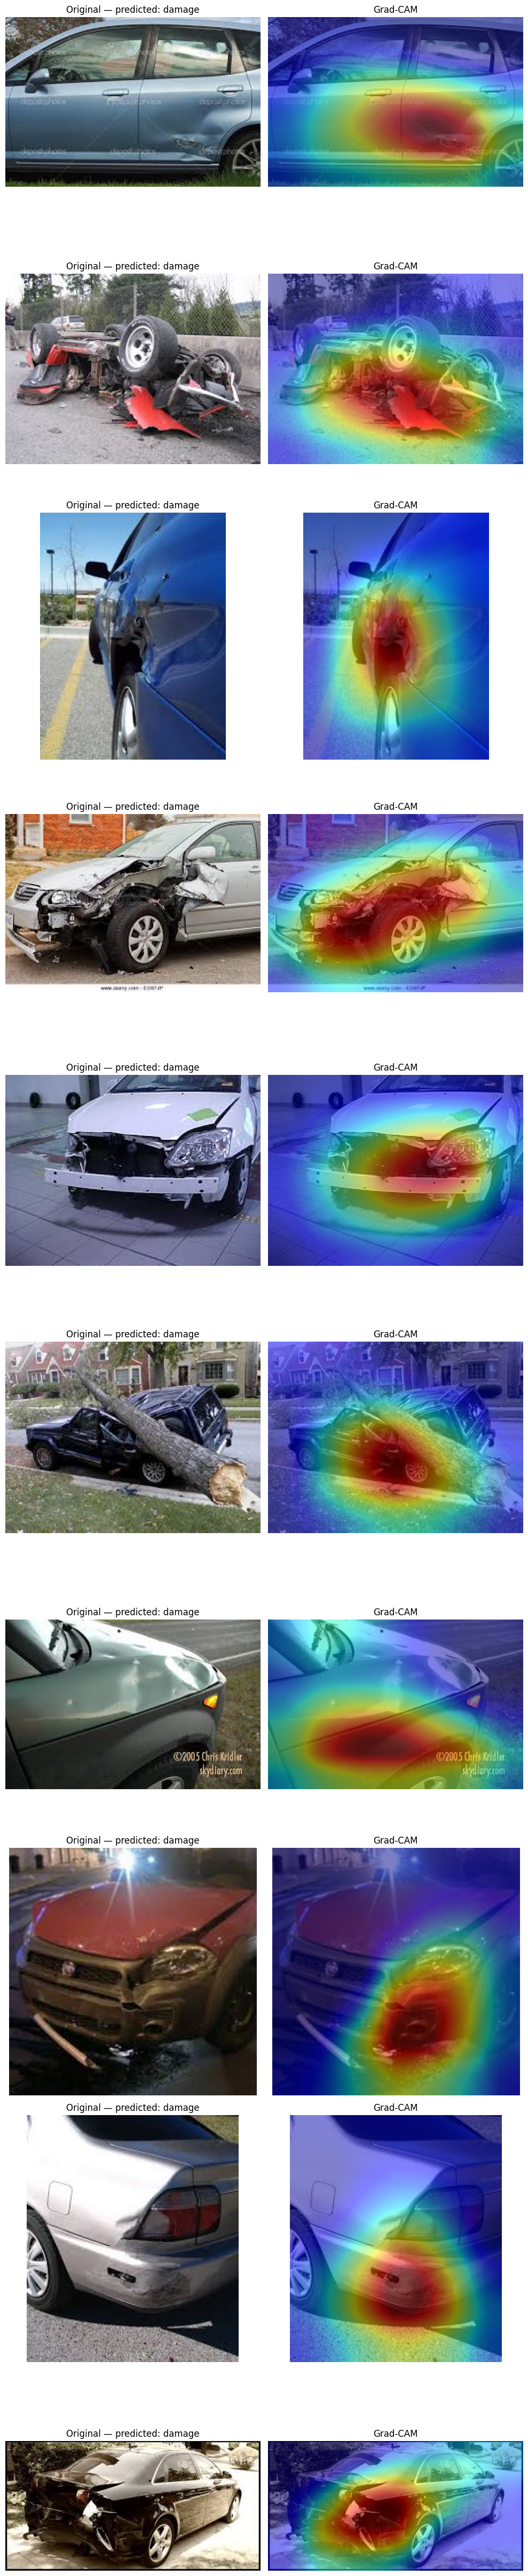

In [34]:
sample_rows = valid_df[valid_df['label']== 0].sample(10, random_state = 42)
img_paths = [os.path.join(valid_root_dir, '00-damage', row['path'])for _, row in sample_rows.iterrows()]

show_gradcam_grid(img_paths, model, valid_transform)

# grad-cam finding on 10 validation images

6/10 correctly predicted damage and heatmap concentrated at the correct damage region.

2/10 correctly predicted damage but concentrated on the wron region (suggests model sometimes relies on proxy cues rather than damage)

2/10 incorrectly predicted whole when it was damaged, heatmap was scattered

in conclusion the model is right for the right reasons most of the time, but not always



In [35]:
true_labels[:20]

[0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0]

In [36]:
predicted_labels[:20]

[0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0]

In [37]:
from sklearn.metrics import classification_report
print(classification_report(true_labels, predicted_labels, target_names= ['damage', 'whole']))

              precision    recall  f1-score   support

      damage       0.97      0.97      0.97       230
       whole       0.97      0.97      0.97       230

    accuracy                           0.97       460
   macro avg       0.97      0.97      0.97       460
weighted avg       0.97      0.97      0.97       460



In [38]:
mismatched_idx = [i for i  in range(len(true_labels)) if true_labels[i] != predicted_labels[i]]
print(f'Number of mismatched labels: {(len(mismatched_idx))}')

Number of mismatched labels: 15


In [39]:
valid_damage = os.listdir(os.path.join(valid_root_dir, '00-damage'))
valid_whole = os.listdir(os.path.join(valid_root_dir, '01-whole'))
valid_df = pd.DataFrame({
    'path': valid_damage + valid_whole,
    'label': [0] * len(valid_damage) + [1] * len(valid_whole)
})

In [40]:
mismatched_df = valid_df.iloc[mismatched_idx].copy()
mismatched_df['true_labels'] = [true_labels[i] for i in mismatched_idx]
mismatched_df['pred_labels'] = [predicted_labels[i] for i in mismatched_idx]

In [41]:
label_names = {0: 'damaged', 1: 'whole'}

# Mismatched-grid to view all the incorrect predictions

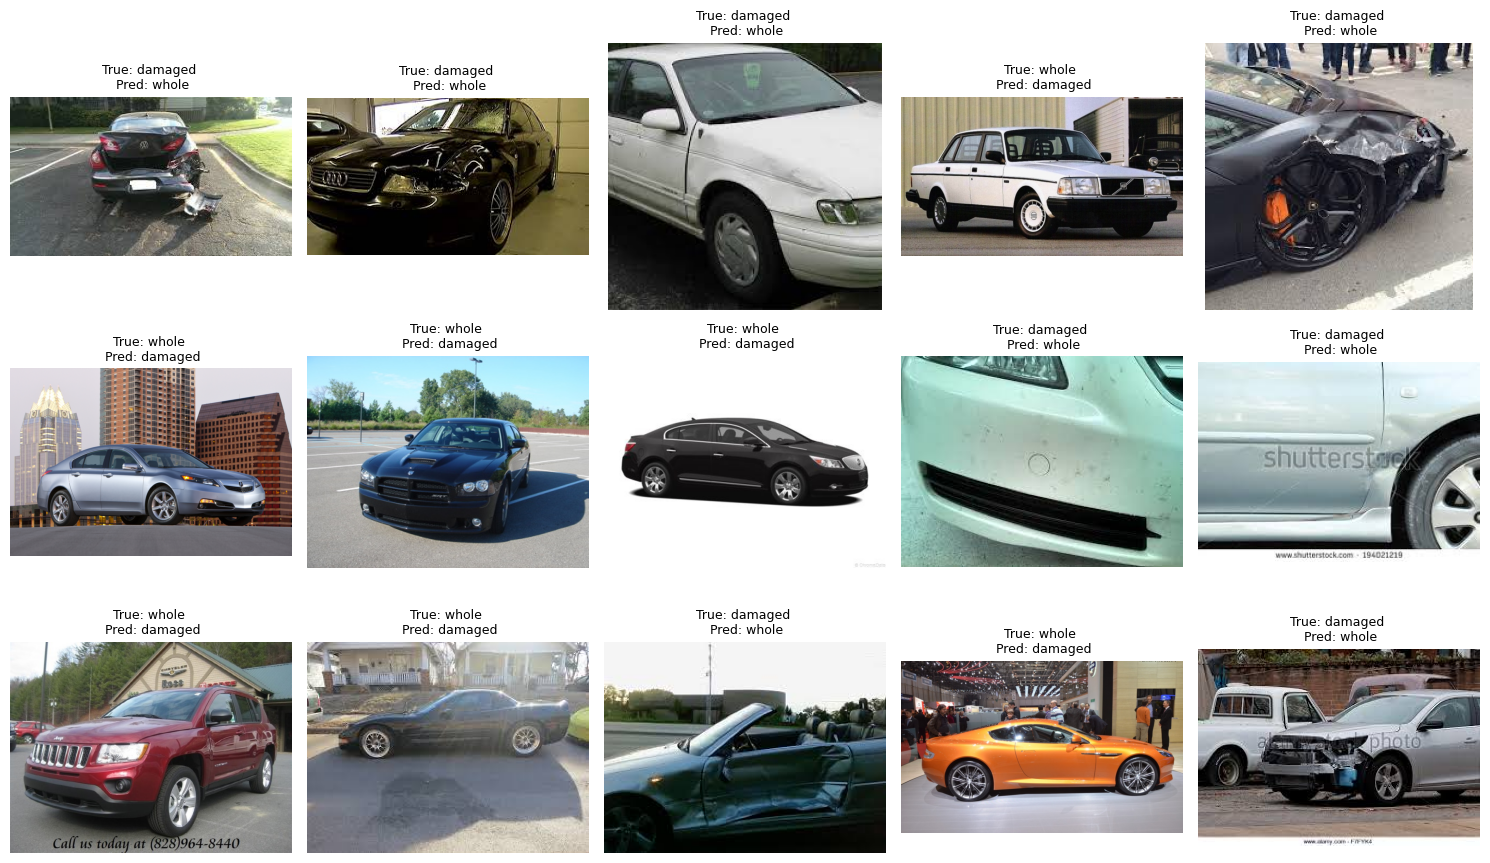

In [42]:
import glob

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

for ax, (_, row) in zip(axes, mismatched_df.iterrows()):
  folder =['00-damage','01-whole'][row['true_labels']]

  base_name = os.path.splitext(row['path'])[0]
  matches = glob.glob(os.path.join(valid_root_dir, folder, f'{base_name}.*'))
  img_path = matches[0]

  img = Image.open(img_path).convert('RGB')
  ax.imshow(img)
  ax.set_title(f'True: {label_names[row["true_labels"]]} \n Pred: {label_names[row["pred_labels"]]}', fontsize=9)
  ax.axis('off')

plt.tight_layout()
plt.show()

In [43]:
# Use the model on a single image from the internet

In [44]:
import requests
from io import BytesIO

img = 'https://imgs.search.brave.com/3NZSHFgDHxWcBfAPib1w3jgJNOQnc0GGc46sGPzqmd4/rs:fit:860:0:0:0/g:ce/aHR0cHM6Ly91cGxv/YWQud2lraW1lZGlh/Lm9yZy93aWtpcGVk/aWEvY29tbW9ucy8x/LzE3L0F1ZGlfUjhf/KDg2Njc2MzI3NTUp/Xyhjcm9wcGVkKS5q/cGc'
response = requests.get(img)
img = Image.open(BytesIO(response.content)).convert('RGB')

img = valid_transform(img)
img = img.unsqueeze(0).to(device)
model.eval()

with torch.no_grad():
  output =model(img)
  _, predicted = torch.max(output, 1)
  label = folder[predicted.item()]

probs = torch.nn.functional.softmax(output, dim=1) #applies softmax to convert logits to probabilities that sunm to 1
confidence = probs[0][predicted.item()].item()

print(f'Prediction: {folder[predicted.item()]} Confidence :{confidence * 100:.2f}%')

Prediction: 0 Confidence :99.88%


# ROC curve and AUC

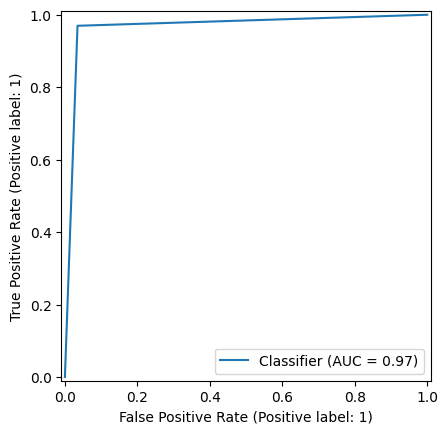

In [45]:
from sklearn.metrics import RocCurveDisplay, auc

RocCurveDisplay.from_predictions(true_labels, predicted_labels)



In [46]:
!pip install gradio

## Creading a UI for the predictions with Gradio

In [47]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 108.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 112.4 MB/s eta 0:00:00


In [48]:
%%writefile app.py
import streamlit as st
import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import Image

model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 2)

model.load_state_dict(torch.load('best_model.pth'))
model.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

label_map = {0: 'Damaged', 1: 'Clean'} #prefered clean here because its faster to grasp

def predict(image):
  image = image.convert('RGB')
  image = transforms(image).unsqueeze(0) # adds a batch dimension because thats what the model expects

  with torch.no_grad():
    output = model(image)
    probs = torch.softmax(output, dim=1)
    conf, pred = torch.max(probs, dim=1)

  label = label_map[pred.item()] #turns numeric class to readable label
  confidence = conf.item() * 100
  return label, confidence

st.title('Car Damage Classifier')
st.write('Upload an image of a car and the model will check whether it is damaged or clean.')

uploaded_file = st.file_uploader('Upload an image', type=['jpg','jpeg', 'png', 'webp','bmp'])

if uploaded_file is not None:
  image =Image.open(uploaded_file)
  st.image(image, caption = 'Uploaded Image', use_container_width = True)

  label, confidence = predict(image)
  st.write(f'Prediction: {label} ({confidence:.2f}% Confidence)')

Writing app.py
